In [ ]:
!pip install -q kagglehub gensim
!pip install nltk
import os
import re
import nltk
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import RegexpTokenizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from gensim.models import Word2Vec
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import kagglehub # Para descargar el dataset
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model


In [ ]:
# Descargar el dataset
path = kagglehub.dataset_download("yasserh/imdb-movie-ratings-sentiment-analysis")
print("Dataset descargado en:", path)

Using Colab cache for faster access to the 'imdb-movie-ratings-sentiment-analysis' dataset.
Dataset descargado en: /kaggle/input/imdb-movie-ratings-sentiment-analysis


In [ ]:
#Cargamos el dataset en un dataframe
data = pd.read_csv(os.path.join(path, "movie.csv"))
data.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [ ]:
#Se encontraron 277 duplicados, aprox el 5% del total del dataset.
duplicados = data[data.duplicated()]
print(duplicados)

                                                    text  label
2164   I find it rather useless to comment on this "m...      0
3236   An absolutely atrocious adaptation of the wond...      0
3428   When I first saw this film it was not an impre...      0
3652   Before I watched this tv movie I did not know ...      1
3787   What a clunker!<br /><br />It MUST have been m...      0
...                                                  ...    ...
39229  I Enjoyed Watching This Well Acted Movie Very ...      1
39246  You do realize that you've been watching the E...      0
39508  (Spoilers)<br /><br />Oh sure it's based on Mo...      0
39681  It's been a long time since I last saw a movie...      0
39746  Goodnight, Mister Tom begins in an impossibly ...      0

[277 rows x 2 columns]


In [ ]:
x_raw = data['text']
y_raw = data['label']

In [ ]:
# Generacion de set de datos para evidencia del desempeño del método construido
x, x_inference, y, y_inference = train_test_split(x_raw, y_raw, test_size=0.01, random_state=42, stratify=data['label'])

In [ ]:
x_raw = x
y_raw = y

In [ ]:
nltk.download(['stopwords', 'snowball_data', 'punkt'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package snowball_data to /root/nltk_data...
[nltk_data]   Package snowball_data is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Preprocesamiento optimizado: NO se hace stemming para no destruir polaridad
# Stopwords solo se eliminan parcialmente
def limpiar_texto(textos):
    return textos.apply(
        lambda t: re.sub(
            r"http\S+|www\S+|https\S+|\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b",
            "",
            str(t).lower()
        )
    )

def preprocesar_y_normalizar(textos):
    tokenizer = RegexpTokenizer(r"\w+")
    stop_words = set(stopwords.words("english"))

    # Conservamos algunas stopwords relevantes para sentimiento
    stop_words -= {"not", "no", "very"}

    procesados = []
    for texto in textos:
        tokens = tokenizer.tokenize(texto.lower())
        tokens = [w for w in tokens if w not in stop_words]
        procesados.append(" ".join(tokens))

    return pd.Series(procesados)


In [ ]:
# Clase para el el preprocesmiento del embbending con Word2vec
class Word2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=300, window=5, min_count=1, workers=4, max_len=200):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.max_len = max_len
        self.model = None

    def fit(self, X, y=None):
        tokenized = [
            t.split() if isinstance(t, str) else []
            for t in X
        ]

        self.model = Word2Vec(
            sentences=tokenized,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers
        )
        return self

    def transform(self, X):
        if self.model is None:
            raise RuntimeError("Debes llamar fit antes de transform")

        tokenized = [t.split() if isinstance(t, str) else [] for t in X]

        sequences = []
        for tokens in tokenized:
            vecs = [self.model.wv[w] for w in tokens if w in self.model.wv]
            sequences.append(vecs)

        padded = pad_sequences(
            sequences,
            maxlen=self.max_len,
            dtype="float32",
            padding="post",
            truncating="post"
        )

        return padded


In [ ]:
# Armado del Pipeline
MAX_SEQUENCE_LENGTH = 70 # Por poco procesamiento y limitacones me memoria RAM, solo es posible ejecutar hasta 70 secuencias de tamano 70, que pudier ser pequeño pero es una limitacion del ambiente de colabs donde es ejecutado
N_COMPONENTES = 200

pipeline_w2v = Pipeline([
    ('limpieza', FunctionTransformer(limpiar_texto)),
    ('preprocesamiento', FunctionTransformer(preprocesar_y_normalizar)),
    ('word2vec', Word2VecTransformer(
        vector_size=N_COMPONENTES,
        window=5,
        min_count=1,
        max_len=MAX_SEQUENCE_LENGTH
    ))
])


In [ ]:
# Fit y transform del Pipeline y slpit de datos de entrenamiento 80%, 20% validación y pruebas (10% y 10%)
X = pipeline_w2v.fit_transform(x_raw)
y = y_raw

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

embedding_dim = X_train.shape[2]
timesteps = X_train.shape[1]


In [ ]:
# --- Definición del Modelo GRU ---
model_gru = Sequential()

# Primera capa GRU (DEBE devolver secuencias)
# Las capas GRU usan 'units' (número de unidades o neuronas) de manera idéntica a LSTM.
model_gru.add(GRU(
    units=128,
    input_shape=(timesteps, embedding_dim),
    return_sequences=True,  # 💡 CLAVE: Debe ser True para alimentar la siguiente GRU
    recurrent_dropout=0.2,

))

# Segunda capa GRU (NO devuelve secuencias)
model_gru.add(GRU(
    units=64, # Puede ser menor que la primera
    return_sequences=False,
    recurrent_dropout=0.2,
    kernel_regularizer=L2(1e-4)
))

model_gru.add(Dropout(0.4)) # Cambiamos de 0.3 a 0.4 por overfitting
model_gru.add(Dense(1, activation='sigmoid')) # Capa de salida binaria para clasificación de sentimiento

# --- Compilación del Modelo ---
optimizer_gru = tf.keras.optimizers.Adam(learning_rate=1e-4) # Manteniendo el mismo learning rate (0.0001)
model_gru.compile(optimizer=optimizer_gru, loss='binary_crossentropy', metrics=['accuracy'])

print("--- Arquitectura del Modelo GRU ---")
model_gru.summary()
print("------------------------------------")

--- Arquitectura del Modelo GRU ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 70, 128)        │       126,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,033 (640.75 KB)

 Trainable params: 164,033 (640.75 KB)

 Non-trainable params: 0 (0.00 B)

------------------------------------


In [ ]:
print("------------------------------------")

# --- Callbacks (Reutilizando los mismos) ---
callbacks_gru = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    # Cambia el nombre del archivo para guardar el mejor modelo GRU
    ModelCheckpoint('best_sentiment_model_GRU.h5', monitor='val_accuracy', save_best_only=True)
]

# --- Entrenamiento del Modelo (Asegúrate de tener X_train, y_train, X_val, y_val definidos) ---
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks_gru
)

# --- Evaluación (Asegúrate de tener X_test, y_test definidos) ---
loss_gru, accuracy_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Precisión Final en el Conjunto de Prueba (GRU): {accuracy_gru:.4f}")

------------------------------------
Epoch 1/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5939 - loss: 0.6752

495/495 ━━━━━━━━━━━━━━━━━━━━ 115s 225ms/step - accuracy: 0.5941 - loss: 0.6751 - val_accuracy: 0.7803 - val_loss: 0.5124
Epoch 2/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7866 - loss: 0.5007

495/495 ━━━━━━━━━━━━━━━━━━━━ 109s 220ms/step - accuracy: 0.7866 - loss: 0.5007 - val_accuracy: 0.8250 - val_loss: 0.4315
Epoch 3/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8151 - loss: 0.4508

495/495 ━━━━━━━━━━━━━━━━━━━━ 109s 220ms/step - accuracy: 0.8151 - loss: 0.4508 - val_accuracy: 0.8356 - val_loss: 0.4040
Epoch 4/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8185 - loss: 0.4344

495/495 ━━━━━━━━━━━━━━━━━━━━ 109s 220ms/step - accuracy: 0.8185 - loss: 0.4344 - val_accuracy: 0.8376 - val_loss: 0.3884
Epoch 5/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8294 - loss: 0.4088

...

495/495 ━━━━━━━━━━━━━━━━━━━━ 110s 222ms/step - accuracy: 0.8546 - loss: 0.3495 - val_accuracy: 0.8556 - val_loss: 0.3401
Epoch 13/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 110s 223ms/step - accuracy: 0.8605 - loss: 0.3423 - val_accuracy: 0.8528 - val_loss: 0.3446
Epoch 14/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8618 - loss: 0.3384

495/495 ━━━━━━━━━━━━━━━━━━━━ 110s 222ms/step - accuracy: 0.8618 - loss: 0.3384 - val_accuracy: 0.8578 - val_loss: 0.3408
Epoch 15/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 111s 223ms/step - accuracy: 0.8638 - loss: 0.3303 - val_accuracy: 0.8576 - val_loss: 0.3357
Epoch 16/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8658 - loss: 0.3261

495/495 ━━━━━━━━━━━━━━━━━━━━ 111s 224ms/step - accuracy: 0.8658 - loss: 0.3261 - val_accuracy: 0.8591 - val_loss: 0.3332
Epoch 17/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 116s 234ms/step - accuracy: 0.8646 - loss: 0.3292 - val_accuracy: 0.8553 - val_loss: 0.3347
Epoch 18/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8720 - loss: 0.3154

495/495 ━━━━━━━━━━━━━━━━━━━━ 109s 221ms/step - accuracy: 0.8720 - loss: 0.3154 - val_accuracy: 0.8606 - val_loss: 0.3327
Epoch 19/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 110s 222ms/step - accuracy: 0.8730 - loss: 0.3153 - val_accuracy: 0.8606 - val_loss: 0.3286
Epoch 20/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8716 - loss: 0.3116

495/495 ━━━━━━━━━━━━━━━━━━━━ 110s 223ms/step - accuracy: 0.8716 - loss: 0.3116 - val_accuracy: 0.8624 - val_loss: 0.3298

✅ Precisión Final en el Conjunto de Prueba (GRU): 0.8510


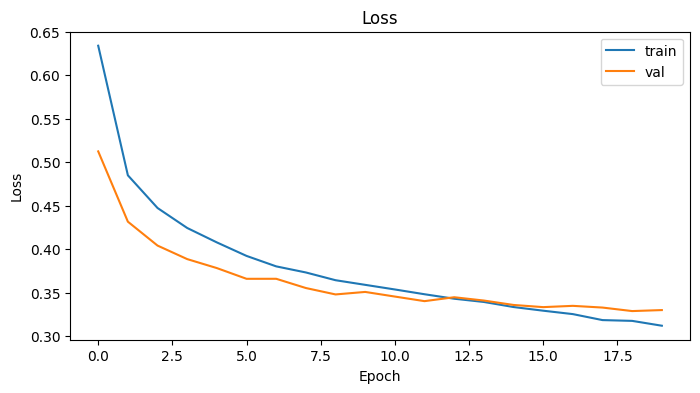

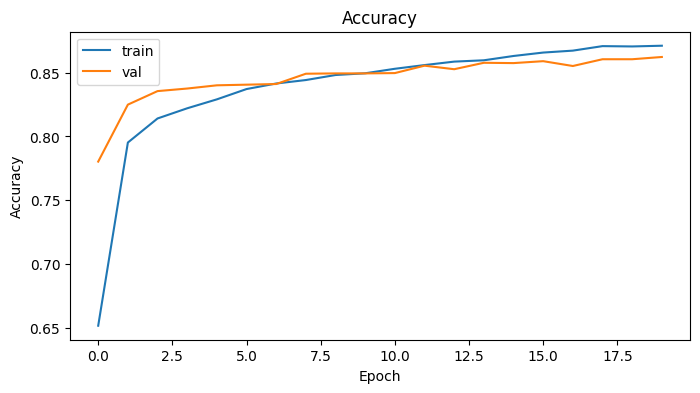

In [ ]:
# LOSS
plt.figure(figsize=(8,4))
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'])
plt.show()

# ACCURACY
plt.figure(figsize=(8,4))
plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'])
plt.show()


124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step


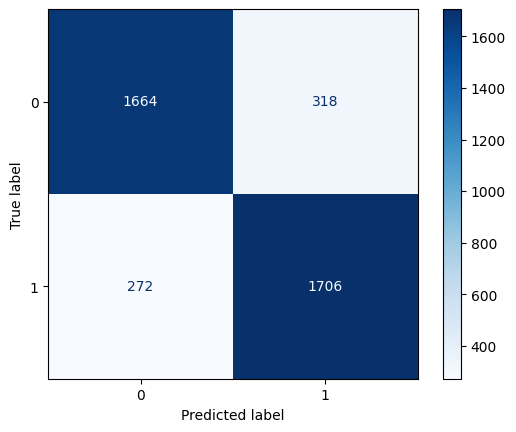

In [ ]:
y_pred = (model_gru.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.show()


In [ ]:

# Transformamos el conjunto de datos separado para la inferencia.
print("Aplicando pipeline W2V a x_inference...")
x_inference_processed = pipeline_w2v.transform(x_inference)
print(f"Forma de los datos procesados: {x_inference_processed.shape}")

# Cargar el Mejor Modelo Entrenado
try:
    best_model_gru = load_model('best_sentiment_model_GRU.h5')
    print("Modelo GRU cargado exitosamente.")
except Exception as e:
    print(f"ADVERTENCIA: Error al cargar el modelo. Usando el modelo en memoria (model_gru). Error: {e}")
    best_model_gru = model_gru # Fallback si el archivo .h5 no está

# Realizar la Inferencia ---

# Obtener las probabilidades (valores entre 0 y 1)
inference_probabilities = best_model_gru.predict(x_inference_processed)

# Convertir las probabilidades a etiquetas binarias (0 o 1)
# Si la probabilidad es >= 0.5, se clasifica como 1 (Positivo)
y_pred_inference = (inference_probabilities > 0.5).astype(int)

# Asegurarse de que y_inference es un array 1D para las métricas de sklearn
if y_inference.ndim > 1:
    y_true = y_inference.flatten()
else:
    y_true = y_inference


# Mostrar y Evaluar Resultados de Inferencia
print("\n--- Resultados de Inferencia ---")
print(f"Total de muestras de inferencia: {len(x_inference_processed)}")

# Métricas Detalladas (Usando sklearn) ---

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred_inference)
print("\nMatriz de Confusión:")
print(cm)

# Reporte de Clasificación Detallado
report = classification_report(y_true, y_pred_inference, target_names=['Negativo (0)', 'Positivo (1)'])
print("\nReporte de Clasificación (Inferencia):")
print(report)

Aplicando pipeline W2V a x_inference...


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Forma de los datos procesados: (400, 70, 200)
Modelo GRU cargado exitosamente.
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step

--- Resultados de Inferencia ---
Total de muestras de inferencia: 400

Matriz de Confusión:
[[171  29]
 [ 24 176]]

Reporte de Clasificación (Inferencia):
              precision    recall  f1-score   support

Negativo (0)       0.88      0.85      0.87       200
Positivo (1)       0.86      0.88      0.87       200

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



In [ ]:
# Definir cuántas muestras aleatorias queremos ver
NUM_SAMPLES = 10
total_samples = len(x_inference)

if total_samples < NUM_SAMPLES:
    NUM_SAMPLES = total_samples
    print(f"Ajustando el número de muestras a {NUM_SAMPLES}.")

random_indices = random.sample(range(total_samples), NUM_SAMPLES)

# Preparar listas para la tabla
textos = []
probabilidades = []
predicciones = []
etiquetas_reales = []
resultados = []

# Iterar sobre los índices y recolectar los datos
for idx in random_indices:

    # 1. Acceso a los datos (usando .iloc como se corrigió anteriormente)
    texto_sucio = x_inference.iloc[idx]
    true_class = y_inference.iloc[idx]
    prob = inference_probabilities[idx][0]
    pred_class = y_pred_inference[idx][0]

    # Esto elimina el padding a la izquierda y es CRUCIAL para la alineación.
    texto_limpio = texto_sucio.lstrip()

    # 2. Mapeo a etiquetas de texto
    sentimiento_predicho = "POSITIVO" if pred_class == 1 else "NEGATIVO"
    sentimiento_real = "POSITIVO" if true_class == 1 else "NEGATIVO"
    resultado = "✅ Correcto" if pred_class == true_class else "❌ Error"

    # Agregar a las listas
    textos.append(texto_limpio) # AÑADIR EL TEXTO LIMPIO
    probabilidades.append(f"{prob:.4f}")
    predicciones.append(sentimiento_predicho)
    etiquetas_reales.append(sentimiento_real)
    resultados.append(resultado)

# Crear el DataFrame de Pandas
df_resumen = pd.DataFrame({
    'Texto Original': textos,
    'Prob. Positiva': probabilidades,
    'Predicción GRU': predicciones,
    'Etiqueta Real': etiquetas_reales,
    'Resultado': resultados
})

# eliminando el desplazamiento y alineando visualmente el texto.
pd.set_option('display.max_colwidth', 150)
# ---------------------------------------------

print("\n--- Resumen de Inferencia Aleatoria (GRU) ---")
print(df_resumen)

# Opcional: Reestablecer el ancho de columna después de imprimir si es necesario
# pd.set_option('display.max_colwidth', None)


--- 📋 Resumen de Inferencia Aleatoria (GRU) ---
                                                                                                                                          Texto Original  \
0  I can't say what knowing the source for this movie adds, but this is one of my favorite films from Paul Mazursky (director and co-author). This is...   
1  (Sorry for my faulty language, i am no native speaker ...)<br /><br />Yes, this is a movie that almost demands an overwhelming reaction. Personall...   
2  End Game started well, the least said about the end the better. it seemed like things we're happening just to keep the plot going, for example the...   
3  The reason why people say that this movie scared them is because it did!! That means the movie purpose was felt by a few who did see it. When I fi...   
4  Film starts with 3 people meeting each other in the bar. OK. They're talking about their imaginary lives, lying all the time, with no reason. Stil...   
5  I watch a lo